<h1 style="color: blue; text-align: center;">Project 2: Diabetes Classification Using Artificial Intelligence</h1>

In [5]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
(100000, 9)
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


<h1 style="color: blue; text-align: center;"> : MISSING VALUES</h1>tax


In [6]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


<h1 style="color: blue; text-align: center;">3: STATISTICAL SUMMARY</h1>

In [7]:
print(df.describe())


                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

<h1 style="color: blue; text-align: center;">: TARRGET CHECK</h1>
diabetes = 0 → No diabetes

diabetes = 1 → Diabetes

In [8]:
print(df["diabetes"].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


<h1 style="color: blue; text-align: center;">: X AND Y DEFINE</h1>

In [9]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print(X.head())
print(y.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  
0          6.6                  140  
1          6.6                   80  
2          5.7                  158  
3          5.0                  155  
4          4.8                  155  
0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64


One-Hot Encoding

In [10]:
X = pd.get_dummies(X, columns=["gender", "smoking_history"], drop_first=True)

print(X.head())
print(X.shape)

    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   gender_Male  gender_Other  smoking_history_current  smoking_history_ever  \
0        False         False                    False                 False   
1        False         False                    False                 False   
2         True         False                    False                 False   
3        False         False                     True                 False   
4         True         False                     True                 False   

   smoking_history_former  smoking_his

TRAIN / TEST SPLIT

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 13)
Testing data: (20000, 13)


<h1 style="color: blue; text-align: center;">: CLASSIFICATION ALGORITHM</h1>


In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

In [13]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


<h1 style="color: blue; text-align: center;">: MODEL PREDICTED VALUE</h1>

In [14]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 ... 0 0 0]


ACCURACY CALCULATION

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9513
Accuracy percentage: 95.13000000000001 %


<h1 style="color: blue; text-align: center;">: CLASSIFICATION REPORT</h1>

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18300
           1       0.70      0.74      0.72      1700

    accuracy                           0.95     20000
   macro avg       0.84      0.86      0.85     20000
weighted avg       0.95      0.95      0.95     20000



<h1 style="color: blue; text-align: center;">: CONFUSION MATRIX</h1>

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[17768   532]
 [  442  1258]]


<h1 style="color: blue; text-align: center;">: CONFUSION MATRIX SUMMARY</h1>

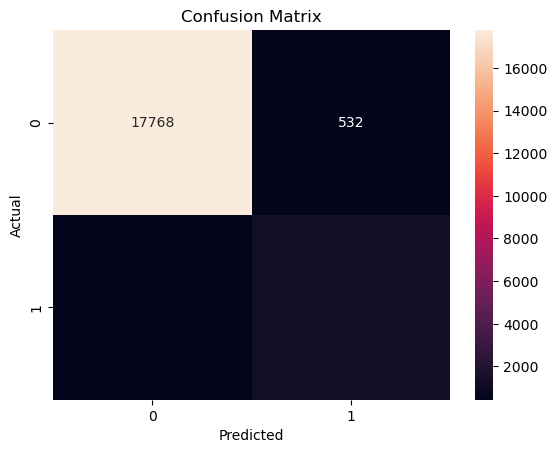

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<h1 style="color: blue; text-align: center;">: FEATURE IMPORTANCE</h1>

In [19]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print(importance.sort_values(ascending=False))

HbA1c_level                    0.489994
blood_glucose_level            0.273344
bmi                            0.117711
age                            0.067105
smoking_history_never          0.010527
gender_Male                    0.009504
smoking_history_former         0.007775
hypertension                   0.005618
smoking_history_not current    0.005340
smoking_history_current        0.004631
heart_disease                  0.004629
smoking_history_ever           0.003821
gender_Other                   0.000000
dtype: float64



<h1 style="color:blue;">: FEATURE IMPORTANCE GRAPH</h1>

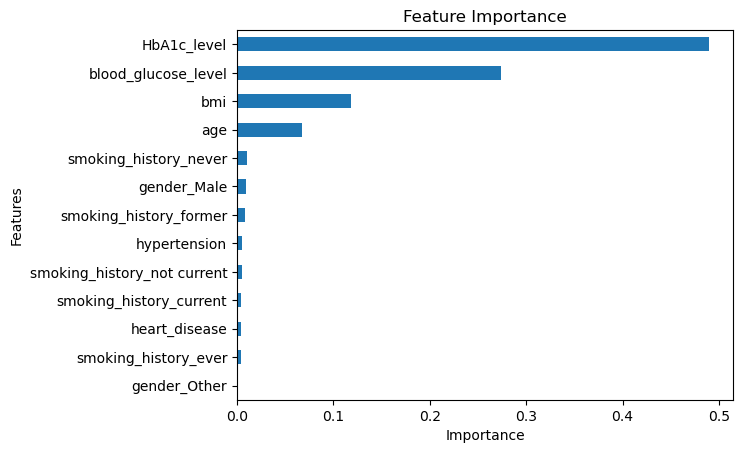

In [20]:
importance.sort_values(ascending=True).plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

FINAL CONCLUSION

print("Project 2: Diabetes Classification")
print("----------------------------------")
print("Algorithm: Decision Tree Classifier")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")